### Übung 8

#### Aufgabe 1 KNN-Algorithmus (10)

Verwenden Sie den unteren Code um sich einen Datensatz zu erstellen.

__a)__ Erstellen Sie ein Scatterplot der Daten, färben Sie die Punkte nach den Klassen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_moons(
    n_samples=1000,
    noise=0.4,
    random_state=42
)

X.shape

(1000, 2)

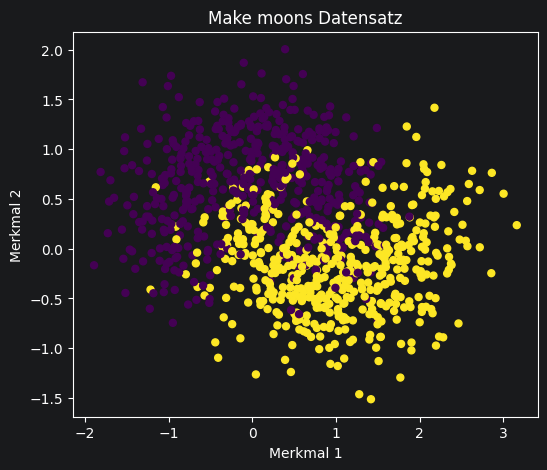

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=25)
plt.title("Make moons Datensatz")
plt.xlabel("Merkmal 1")
plt.ylabel("Merkmal 2")
plt.show()

__b)__ Nutzen Sie die `train_test_split()` Funktion, um sich Trainings- und Testdaten zu generieren. Teilen Sie die Daten dabei in 70% Train und 30% Test ein.

In [4]:
from sklearn.preprocessing import StandardScaler


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(X_train.shape)
print(X_test.shape)

(700, 2)
(300, 2)


__c)__ Verwenden Sie $K=[1, 3, 5, 10, 20, 50, 100,124]$ und _trainineren_ Sie den KNN mit den Trainingsdaten und testen Sie ihn anschließend mit den Testdaten. Speichern Sie dabei als Fehlerfunktion 1-Accuracy für den jeweiligen Lauf (einzeln für Train und Test).

In [5]:
import pandas as pd


k_values = [1, 3, 5, 10, 20, 50, 100, 124]

train_errors = []
test_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_prediction = knn.predict(X_train)
    test_prediction = knn.predict(X_test)

    train_errors.append(1 - accuracy_score(y_train, train_prediction))
    test_errors.append(1 - accuracy_score(y_test, test_prediction))

best_k = int(k_values[np.argmin(test_errors)])

fehler_tabelle = pd.DataFrame({
    "K": k_values,
    "Train-Fehler": train_errors,
    "Test-Fehler": test_errors,
})

fehler_tabelle["Gewähltes K"] = fehler_tabelle["K"] == best_k
fehler_tabelle

,K,Train-Fehler,Test-Fehler,Gewähltes K
0,1,0.000000,0.173333,False
1,3,0.088571,0.143333,False
2,5,0.114286,0.130000,False
3,10,0.138571,0.126667,False
4,20,0.144286,0.116667,True
5,50,0.148571,0.123333,False
6,100,0.152857,0.116667,False
7,124,0.160000,0.116667,False


__d)__ Visualisieren Sie das Ergebnis sinnvoll. Welches $K$ würden Sie wählen?

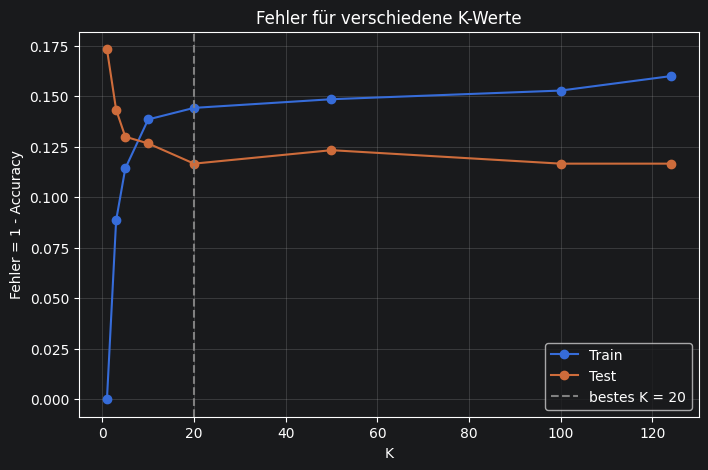

Ich würde K = 20 wählen, weil dort der Testfehler am kleinsten ist.


In [6]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_errors, marker="o", label="Train")
plt.plot(k_values, test_errors, marker="o", label="Test")
plt.axvline(best_k, color="gray", linestyle="--", label=f"bestes K = {best_k}")

plt.title("Fehler für verschiedene K-Werte")
plt.xlabel("K")
plt.ylabel("Fehler = 1 - Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Ich würde K =", best_k, "wählen, weil dort der Testfehler am kleinsten ist.")

Antwort: Ich würde den K-Wert mit dem kleinsten Testfehler wählen. Der konkrete Wert wird im Plot markiert und im Code als `best_k` ausgegeben.

__e)__ Visualisieren Sie die Decision Surfaces für jedes $K$. Verwenden Sie hierfür gerne den Code aus https://data-science-crashkurs.de/chapters/kapitel_07.html, es kann sein, dass Sie ein paar Anpassungen machen müssen. 

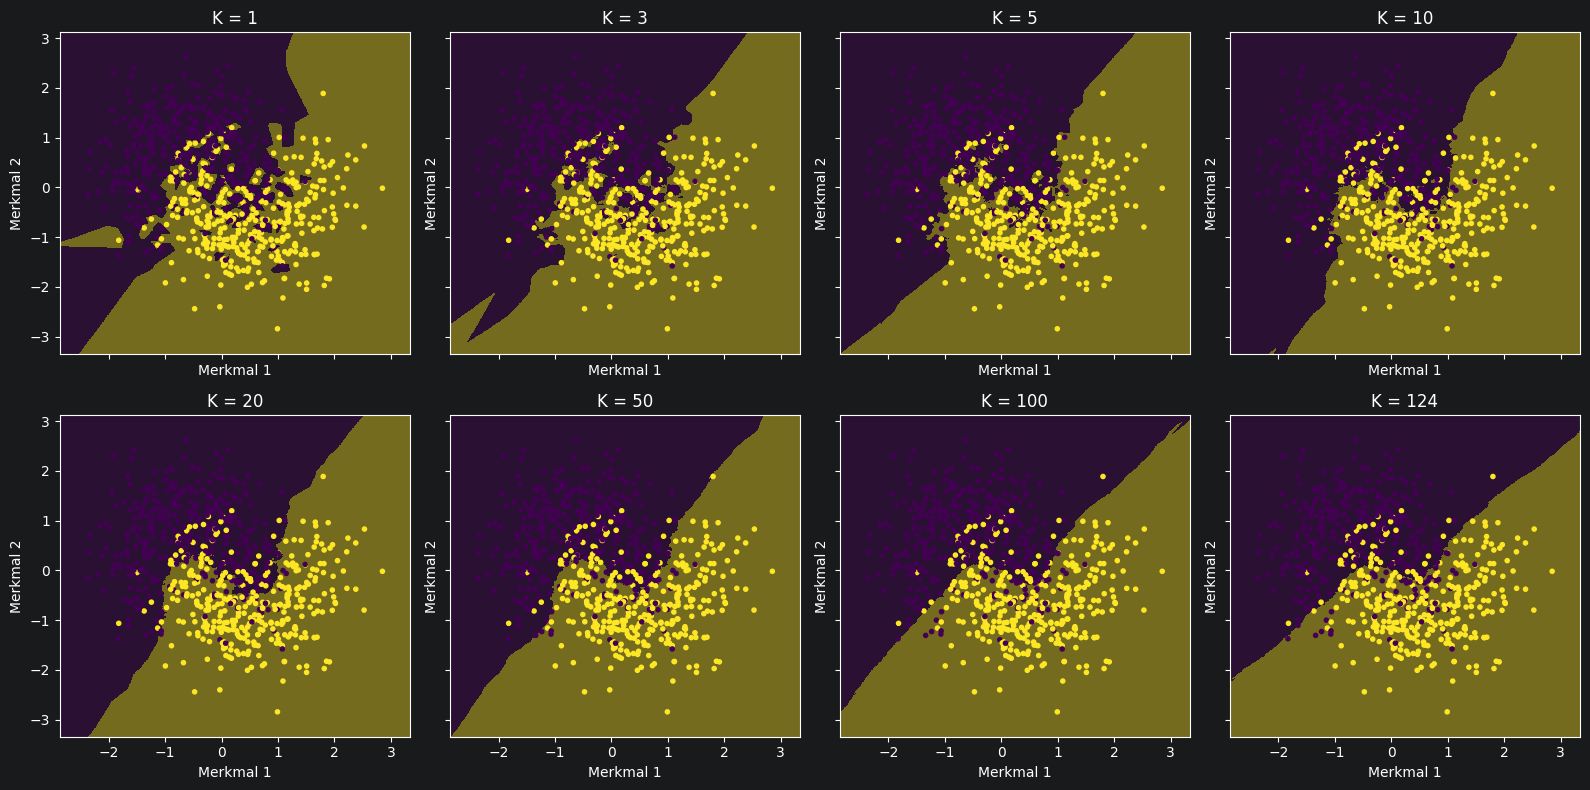

In [7]:
import pandas as pd


# Quelle: https://data-science-crashkurs.de/chapters/kapitel_07.html
def plot_decision_surface(model, X, Y, ax=None, title=None):
    h = .01
    x_min, x_max = X.iloc[:, 0].min() - .5, X.iloc[:, 0].max() + .5
    y_min, y_max = X.iloc[:, 1].min() - .5, X.iloc[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    model.fit(X.values, Y)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    if ax is None:
        plt.figure()
        ax = plt.gca()

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.pcolormesh(xx, yy, Z, alpha=0.4, shading="auto")
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=Y, marker=".", cmap="viridis")

    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])

    if title is None:
        title = str(model)
    ax.set_title(title)


X_train_df = pd.DataFrame(X_train, columns=["Merkmal 1", "Merkmal 2"])

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

for ax, k in zip(axes.ravel(), k_values):
    plot_decision_surface(
        KNeighborsClassifier(n_neighbors=k),
        X_train_df,
        y_train,
        ax=ax,
        title=f"K = {k}"
    )

plt.tight_layout()
plt.show()

__f)__ Erklären Sie das Ergebnis im Sinne von Bias-Variance-Tradeoff.

Antwort: Kleine K-Werte sind sehr flexibel und können stark auf einzelne Trainingspunkte reagieren. Das bedeutet niedriger Bias, aber hohe Varianz. Große K-Werte glätten die Grenze stärker. Das bedeutet niedrigere Varianz, aber höheren Bias. Ein mittleres K ist hier sinnvoll, weil es nicht zu sehr auswendig lernt und trotzdem die Mondform noch gut abbildet.

#### Aufgabe 2: Schummeln mit Train-Test-Split (5)

Verwenden Sie die Daten von Aufgabe 1.

__a)__ Verwenden Sie den KNN-Klassifikator mit dem besten K aus Aufgabe 1. Lassen Sie den `train-test-split` mit unterschiedlichen Seeds laufen. Visualisieren Sie die Accuracy für die unterschiedlichen Läufe (gerne Boxplot, je eines für Train- und Testdaten).

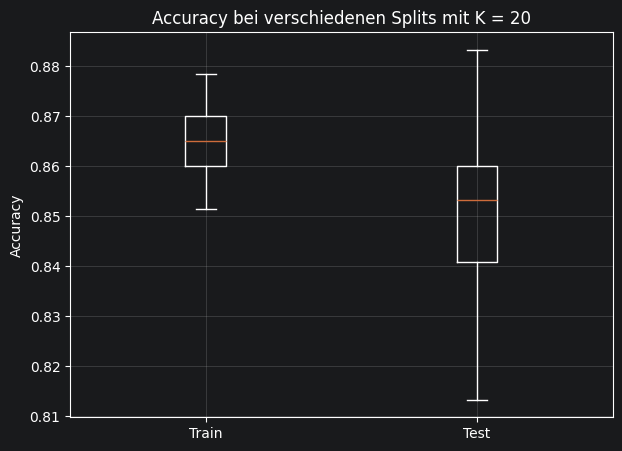

Bestes Train-Ergebnis: 0.8785714285714286
Schlechtestes Train-Ergebnis: 0.8514285714285714
Bestes Test-Ergebnis: 0.8833333333333333
Schlechtestes Test-Ergebnis: 0.8133333333333334


In [9]:
seeds = range(50)

train_accuracies = []
test_accuracies = []

for seed in seeds:
    X_train_seed_raw, X_test_seed_raw, y_train_seed, y_test_seed = train_test_split(
        X,
        y,
        train_size=0.7,
        test_size=0.3,
        random_state=seed,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_seed = scaler.fit_transform(X_train_seed_raw)
    X_test_seed = scaler.transform(X_test_seed_raw)

    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_seed, y_train_seed)

    train_accuracies.append(accuracy_score(y_train_seed, knn.predict(X_train_seed)))
    test_accuracies.append(accuracy_score(y_test_seed, knn.predict(X_test_seed)))

plt.figure(figsize=(7, 5))
plt.boxplot([train_accuracies, test_accuracies], tick_labels=["Train", "Test"])
plt.title(f"Accuracy bei verschiedenen Splits mit K = {best_k}")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

print("Bestes Train-Ergebnis:", max(train_accuracies))
print("Schlechtestes Train-Ergebnis:", min(train_accuracies))
print("Bestes Test-Ergebnis:", max(test_accuracies))
print("Schlechtestes Test-Ergebnis:", min(test_accuracies))

__b)__ Was sind Ihre besten Ergebniss, was Ihre schlechtesten? Was folgern Sie daraus für die Vertrauenswürdigkeit von Ergebnissen aus Machine Learning Experimenten?

Antwort: Das beste und schlechteste Ergebnis können je nach zufälligem Split sichtbar auseinanderliegen. Daraus folgt: Ein einzelner Train-Test-Split ist nur begrenzt vertrauenswürdig. Besser ist es, mehrere Splits oder Cross Validation zu verwenden.

#### Zusatzaufgabe: Cross Validation (10)

__a)__ Eigentlich ist das Vorgehen von Aufgabe 1 für die Findung des besten Ks falsch. Warum?

Antwort: Das Vorgehen aus Aufgabe 1 ist für die Wahl von K nicht sauber, weil das Testset zur Modellauswahl benutzt wird. Dadurch ist das Testset nicht mehr wirklich unabhängig. Besser ist: K mit Cross Validation auf den Trainingsdaten wählen und das Testset erst ganz am Ende verwenden.

__b)__ Verwenden Sie die Trainingsdaten von Aufgabe 1 - erstellen Sie eine 5 _fold cross validation_ (selbst implementiert, nicht mit fertigen sklearn routinen) und führen Sie Aufgabe 1 (außer d)) erneut aus. Für den Fehlerplot, visualisieren Sie nun bitte Mittelwert und Standardabweichungen.

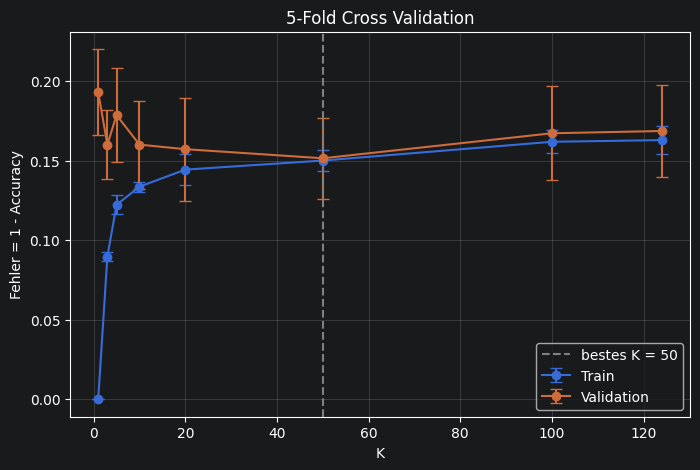

Bestes K nach Cross Validation: 50


In [10]:
folds = 5
rng = np.random.default_rng(42)
indices = np.arange(len(X_train_raw))
rng.shuffle(indices)
fold_indices = np.array_split(indices, folds)

cv_train_mean = []
cv_train_std = []
cv_val_mean = []
cv_val_std = []

for k in k_values:
    fold_train_errors = []
    fold_val_errors = []

    for fold in range(folds):
        val_index = fold_indices[fold]
        train_index = np.concatenate([fold_indices[i] for i in range(folds) if i != fold])

        X_fold_train_raw = X_train_raw[train_index]
        X_fold_val_raw = X_train_raw[val_index]
        y_fold_train = y_train[train_index]
        y_fold_val = y_train[val_index]

        scaler = StandardScaler()
        X_fold_train = scaler.fit_transform(X_fold_train_raw)
        X_fold_val = scaler.transform(X_fold_val_raw)

        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_fold_train, y_fold_train)

        fold_train_errors.append(1 - accuracy_score(y_fold_train, knn.predict(X_fold_train)))
        fold_val_errors.append(1 - accuracy_score(y_fold_val, knn.predict(X_fold_val)))

    cv_train_mean.append(np.mean(fold_train_errors))
    cv_train_std.append(np.std(fold_train_errors))
    cv_val_mean.append(np.mean(fold_val_errors))
    cv_val_std.append(np.std(fold_val_errors))

best_k_cv = int(k_values[np.argmin(cv_val_mean)])

plt.figure(figsize=(8, 5))
plt.errorbar(k_values, cv_train_mean, yerr=cv_train_std, marker="o", capsize=4, label="Train")
plt.errorbar(k_values, cv_val_mean, yerr=cv_val_std, marker="o", capsize=4, label="Validation")
plt.axvline(best_k_cv, color="gray", linestyle="--", label=f"bestes K = {best_k_cv}")

plt.title("5-Fold Cross Validation")
plt.xlabel("K")
plt.ylabel("Fehler = 1 - Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Bestes K nach Cross Validation:", best_k_cv)